In [4]:
# Loading filtered dataset
import pandas as pd

df_filtered = pd.read_csv('df_filtered_cleaned.csv')

print(df_filtered.shape)
df_filtered.head(10)


(32030, 3)


,author_ID,post_cleaned,political_leaning
0,t2_7ramzeng,you can buy the show and stream it through the...,right
1,t2_7ramzeng,me want to play q bert holy shit based alex jo...,right
2,t2_7ramzeng,shouldn t rely on any external services or per...,right
3,t2_7ramzeng,pr to a specific person usually that just mean...,right
4,t2_7ramzeng,this article s intention is clear that they wa...,right
5,t2_7ramzeng,is big and a safe investment by pretending the...,right
6,t2_7ramzeng,but that seems even less likely no that is abs...,right
7,t2_7ramzeng,were living paycheck to paycheck without diffi...,right
8,t2_7ramzeng,this one takes experience to learn how to poin...,right
9,t2_7ramzeng,gloves drops a bag of food in front of the car...,right


In [5]:
df_filtered.info()
df_filtered['political_leaning'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32030 entries, 0 to 32029
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   author_ID          32030 non-null  object
 1   post_cleaned       32030 non-null  object
 2   political_leaning  32030 non-null  object
dtypes: object(3)
memory usage: 750.8+ KB


political_leaning
right    17454
left     14576
Name: count, dtype: int64

In [6]:
# Extracting unique authors
from sklearn.model_selection import train_test_split

# Unique authors
unique_authors = df_filtered['author_ID'].unique()

# The number of uniqe authors
print('Number of unique authors:', len(unique_authors))

Number of unique authors: 1295


In [7]:
# Splitting authors
train_authors, test_authors = train_test_split(unique_authors, random_state = 42, test_size = 0.20)

# The number of test and train set
print('Train set authors: ', len(train_authors))
print('Test set authors:', len(test_authors))

Train set authors:  1036
Test set authors: 259


In [8]:
# Creating test and train sets based on the same author IDs
train_df = df_filtered[df_filtered["author_ID"].isin(train_authors)].copy()
test_df = df_filtered[df_filtered["author_ID"].isin(test_authors)].copy()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (26606, 3)
Test shape: (5424, 3)


In [9]:
# Check author overlap between train and test
overlap_authors = set(train_df["author_ID"]).intersection(set(test_df["author_ID"]))

print("Number of overlapping authors:", len(overlap_authors))

Number of overlapping authors: 0


In [10]:
# Checking the class distribution in train and test sets
print("Train class distribution:")
print(train_df["political_leaning"].value_counts())
print(train_df["political_leaning"].value_counts(normalize=True))

print("\nTest class distribution:")
print(test_df["political_leaning"].value_counts())
print(test_df["political_leaning"].value_counts(normalize=True))

Train class distribution:
political_leaning
right    14585
left     12021
Name: count, dtype: int64
political_leaning
right    0.548185
left     0.451815
Name: proportion, dtype: float64

Test class distribution:
political_leaning
right    2869
left     2555
Name: count, dtype: int64
political_leaning
right    0.528945
left     0.471055
Name: proportion, dtype: float64


In [11]:
# Model's input
X_train = train_df["post_cleaned"]
X_test = test_df["post_cleaned"]

y_train = train_df["political_leaning"]
y_test = test_df["political_leaning"]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (26606,)
X_test: (5424,)
y_train: (26606,)
y_test: (5424,)


In [12]:
# Building the baseline dummyclassifer based on the inputs
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

# Selecting the most frequent strategy in the light of the research 
dummy_clf = DummyClassifier(strategy="most_frequent")

# Fitting the model
dummy_clf.fit(X_train, y_train)
y_pred_dummy = dummy_clf.predict(X_test)
dummy_accuracy = accuracy_score(y_test, y_pred_dummy)

dummy_precision, dummy_recall, dummy_f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred_dummy,
    average="macro",
    zero_division=0
)

print("DummyClassifier Results")
print("Accuracy:", dummy_accuracy)
print("Macro Precision:", dummy_precision)
print("Macro Recall:", dummy_recall)
print("Macro F1:", dummy_f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dummy, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dummy))

DummyClassifier Results
Accuracy: 0.5289454277286135
Macro Precision: 0.26447271386430676
Macro Recall: 0.5
Macro F1: 0.34595441938984683

Classification Report:
              precision    recall  f1-score   support

        left       0.00      0.00      0.00      2555
       right       0.53      1.00      0.69      2869

    accuracy                           0.53      5424
   macro avg       0.26      0.50      0.35      5424
weighted avg       0.28      0.53      0.37      5424


Confusion Matrix:
[[   0 2555]
 [   0 2869]]


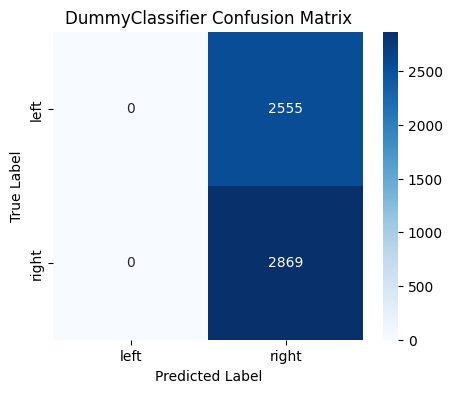

In [13]:
# Visualizing the confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm_dummy = confusion_matrix(y_test, y_pred_dummy, labels=["left", "right"])

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_dummy,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["left", "right"],
    yticklabels=["left", "right"]
)

plt.title("DummyClassifier Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()